# Sleep and the Allocation of Time


## Data Variables and Renaming
The original dataset variables have somewhat cryptic names. We will rename them for clarity.
- `age`: `age` (in years)
- `black`: `is_black` (=1 if black)
- `case`: `case_id` (identifier)
- `clerical`: `is_clerical` (=1 if clerical worker)
- `construc`: `is_construction` (=1 if construction worker)
- `educ`: `education_years` (years of schooling)
- `earns74`: `earnings_1974` (total earnings, 1974)
- `gdhlth`: `is_good_health` (=1 if in good or excellent health)
- `inlf`: `in_labor_force` (=1 if in labor force)
- `leis1`: `leisure_sleep` (sleep - totwrk)
- `leis2`: `leisure_slpnaps` (slpnaps - totwrk)
- `leis3`: `leisure_rlxall` (rlxall - totwrk)
- `smsa`: `lives_in_smsa` (= 1 if live in smsa)
- `lhrwage`: `log_hourly_wage` (log hourly wage)
- `lothinc`: `log_other_income` (log othinc, unless othinc < 0)
- `male`: `is_male` (= 1 if male)
- `marr`: `is_married` (= 1 if married)
- `prot`: `is_protestant` (= 1 if Protestant)
- `rlxall`: `relax_all` (slpnaps + personal activs)
- `selfe`: `is_self_employed` (=1 if self employed)
- `sleep`: `sleep_mins` (mins sleep at night, per week)
- `slpnaps`: `sleep_naps_mins` (mins sleep, including naps, per week) **<- OUR TARGET**
- `south`: `lives_in_south` (=1 if live in south)
- `spsepay`: `spousal_income` (spousal wage income)
- `spwrk75`: `spouse_works` (=1 if spouse works)
- `totwrk`: `total_work_mins` (mins worked per week)
- `union`: `belongs_to_union` (=1 if belong to union)
- `worknrm`: `main_job_work_mins` (mins work main job)
- `workscnd`: `second_job_work_mins` (mins work second job)
- `exper`: `experience_years` (age - educ - 6)
- `yngkid`: `has_young_kid` (=1 if children < 3 present)
- `yrsmarr`: `years_married` (years married)
- `hrwage`: `hourly_wage` (hourly wage)
- `agesq`: `age_squared` (age^2)


In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
import matplotlib.patches as mpatches
import seaborn as sns
from scipy import stats
from sklearn.impute import KNNImputer
import missingno as msno
import warnings
warnings.filterwarnings('ignore')

# Set styling for plots
sns.set_theme(style="whitegrid", palette="muted")


## Data wrangling
We will load the Excel file and assign the original column names, then immediately rename them to our more descriptive names.

In [2]:
# Original columns based on the description file
orig_cols = [
    'age', 'black', 'case', 'clerical', 'construc', 'educ', 'earns74', 'gdhlth', 
    'inlf', 'leis1', 'leis2', 'leis3', 'smsa', 'lhrwage', 'lothinc', 'male', 
    'marr', 'prot', 'rlxall', 'selfe', 'sleep', 'slpnaps', 'south', 'spsepay', 
    'spwrk75', 'totwrk', 'union', 'worknrm', 'workscnd', 'exper', 'yngkid', 
    'yrsmarr', 'hrwage', 'agesq'
]

# Better column names
new_cols = [
    'age', 'is_black', 'case_id', 'is_clerical', 'is_construction', 'education_years', 
    'earnings_1974', 'is_good_health', 'in_labor_force', 'leisure_sleep', 'leisure_slpnaps', 
    'leisure_rlxall', 'lives_in_smsa', 'log_hourly_wage', 'log_other_income', 'is_male', 
    'is_married', 'is_protestant', 'relax_all', 'is_self_employed', 'sleep_mins', 
    'sleep_naps_mins', 'lives_in_south', 'spousal_income', 'spouse_works', 'total_work_mins', 
    'belongs_to_union', 'main_job_work_mins', 'second_job_work_mins', 'experience_years', 
    'has_young_kid', 'years_married', 'hourly_wage', 'age_squared'
]

# Load data without header and apply original columns
file_path = "data/assignment_data/sleep75.xls"
df = pd.read_excel(file_path, header=None, names=orig_cols)

# Rename to new descriptive names
df.columns = new_cols

df.head()

,age,is_black,case_id,is_clerical,is_construction,education_years,earnings_1974,is_good_health,in_labor_force,leisure_sleep,...,spouse_works,total_work_mins,belongs_to_union,main_job_work_mins,second_job_work_mins,experience_years,has_young_kid,years_married,hourly_wage,age_squared
0,32,0,1,0.0,0.0,12,0,0,1,3529,...,0,3438,0,3438,0,14,0,13,7.070004,1024
1,31,0,2,0.0,0.0,14,9500,1,1,2140,...,0,5020,0,5020,0,11,0,0,1.429999,961
2,44,0,3,0.0,0.0,17,42500,1,1,4595,...,1,2815,0,2815,0,21,0,0,20.53,1936
3,30,0,4,0.0,0.0,12,42500,1,1,3211,...,1,3786,0,3786,0,12,0,12,9.619998,900
4,64,0,5,0.0,0.0,14,2500,1,1,4052,...,1,2580,0,2580,0,44,0,33,2.75,4096


### Missing values detection and cleaning

In [3]:
df = df.replace('.', np.nan)
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 706 entries, 0 to 705
Data columns (total 34 columns):
 #   Column                Non-Null Count  Dtype  
---  ------                --------------  -----  
 0   age                   706 non-null    int64  
 1   is_black              706 non-null    int64  
 2   case_id               706 non-null    int64  
 3   is_clerical           706 non-null    float64
 4   is_construction       706 non-null    float64
 5   education_years       706 non-null    int64  
 6   earnings_1974         706 non-null    int64  
 7   is_good_health        706 non-null    int64  
 8   in_labor_force        706 non-null    int64  
 9   leisure_sleep         706 non-null    int64  
 10  leisure_slpnaps       706 non-null    int64  
 11  leisure_rlxall        706 non-null    int64  
 12  lives_in_smsa         706 non-null    int64  
 13  log_hourly_wage       532 non-null    float64
 14  log_other_income      706 non-null    float64
 15  is_male               7

In [4]:
# Check missing values
missing_data = df.isna().sum()
missing_data[missing_data > 0]

log_hourly_wage    174
hourly_wage        174
dtype: int64

### Finding the reason for missing data

In [5]:
# Filter the dataframe to keep only the rows where 'is_clerical' is NOT 0 and NOT 1
weird_rows = df[~df['is_clerical'].isin([0, 1])]
weird_rows[['case_id', 'is_clerical', 'is_construction', 'in_labor_force', 'hourly_wage']].head(10)

,case_id,is_clerical,is_construction,in_labor_force,hourly_wage
532,533,0.182331,0.030075,0,NaN
533,534,0.182331,0.030075,0,NaN
534,535,0.182331,0.030075,0,NaN
535,536,0.182331,0.030075,0,NaN
536,537,0.182331,0.030075,0,NaN
537,538,0.182331,0.030075,0,NaN
538,539,0.182331,0.030075,0,NaN
539,540,0.182331,0.030075,0,NaN
540,541,0.182331,0.030075,0,NaN
541,542,0.182331,0.030075,0,NaN


For the variables `is_clerical` and `is_construction` (which should be strictly 0 or 1), respondents at the very end of the file have values of `0.182331` and `0.030075`. 

It might suggest that the original authors had missing values for these individuals and decided to use **mean imputation** (filling in the sample average).

To fix this, we will revert these specific erroneous values back to `NaN` so we can impute them properly later.

In [6]:
df.loc[np.isclose(df['is_clerical'], 0.182331), 'is_clerical'] = np.nan
df.loc[np.isclose(df['is_construction'], 0.030075), 'is_construction'] = np.nan

<Axes: >

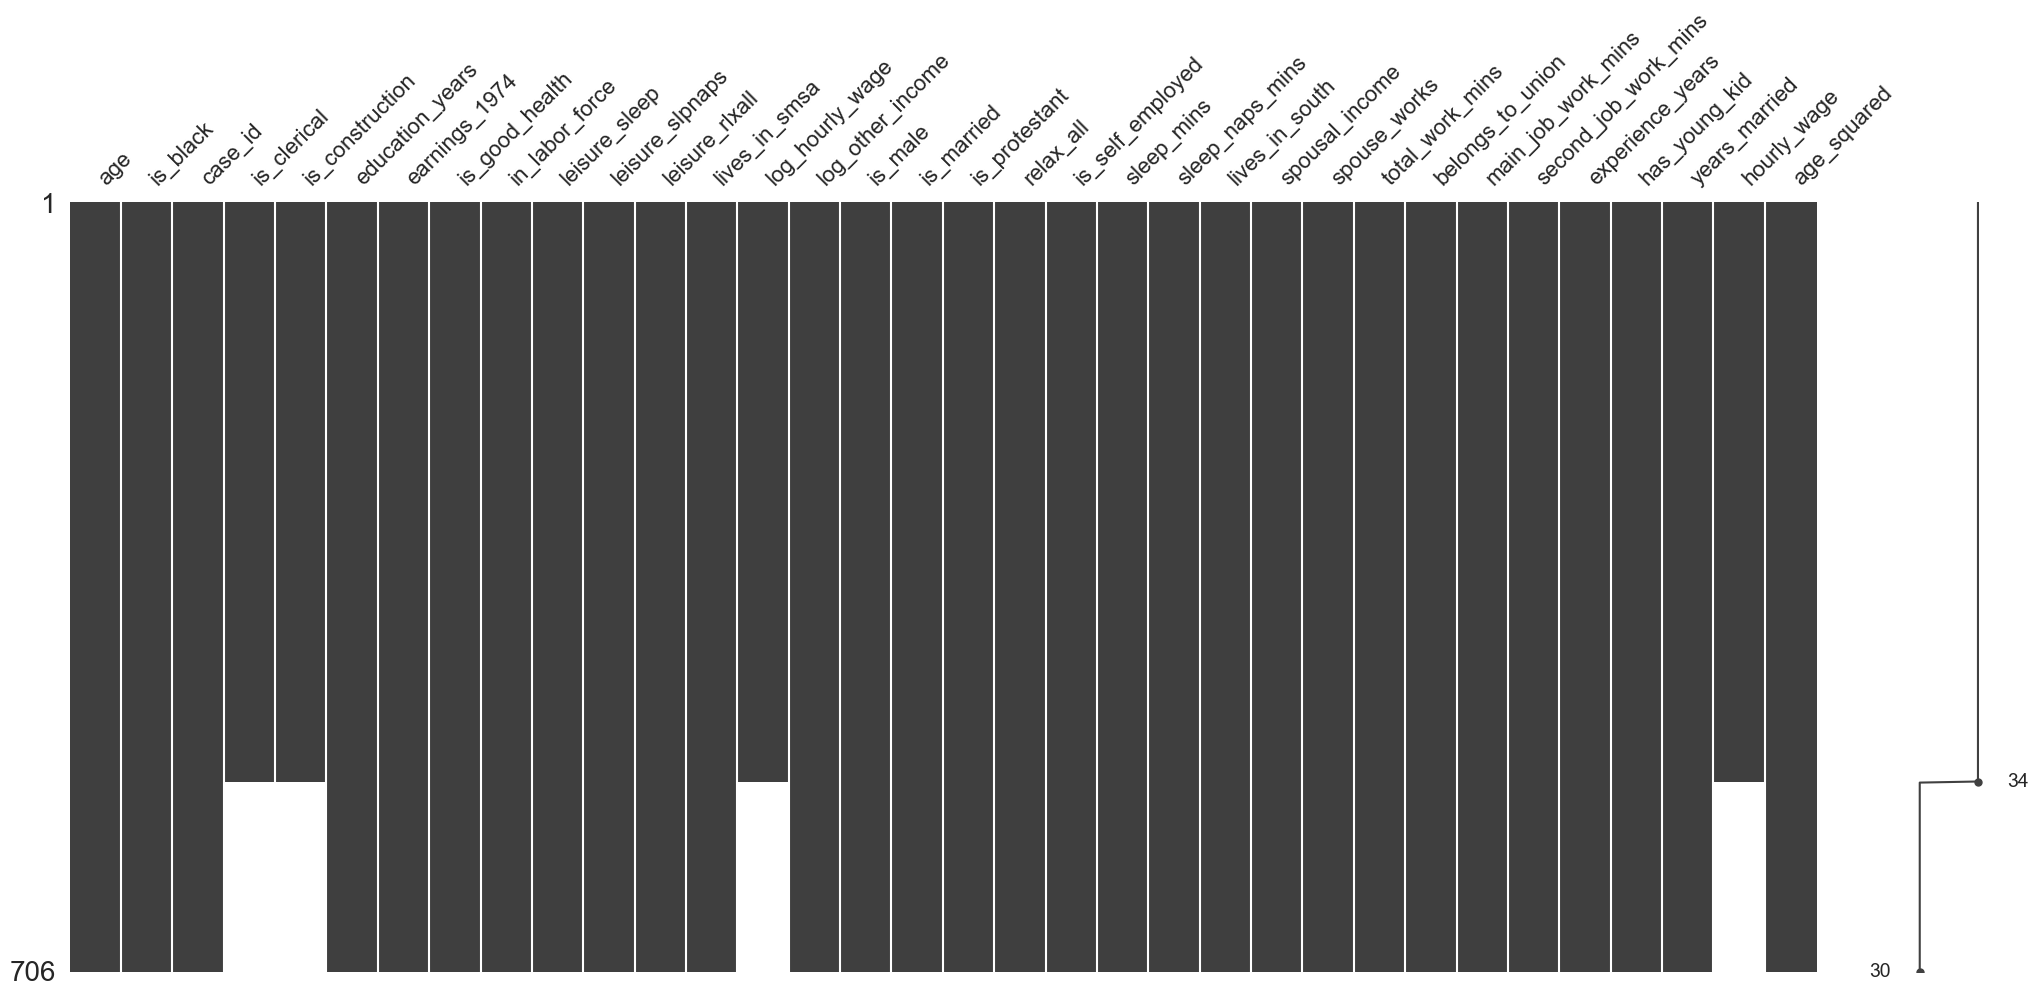

In [7]:
msno.matrix(df)

<Axes: >

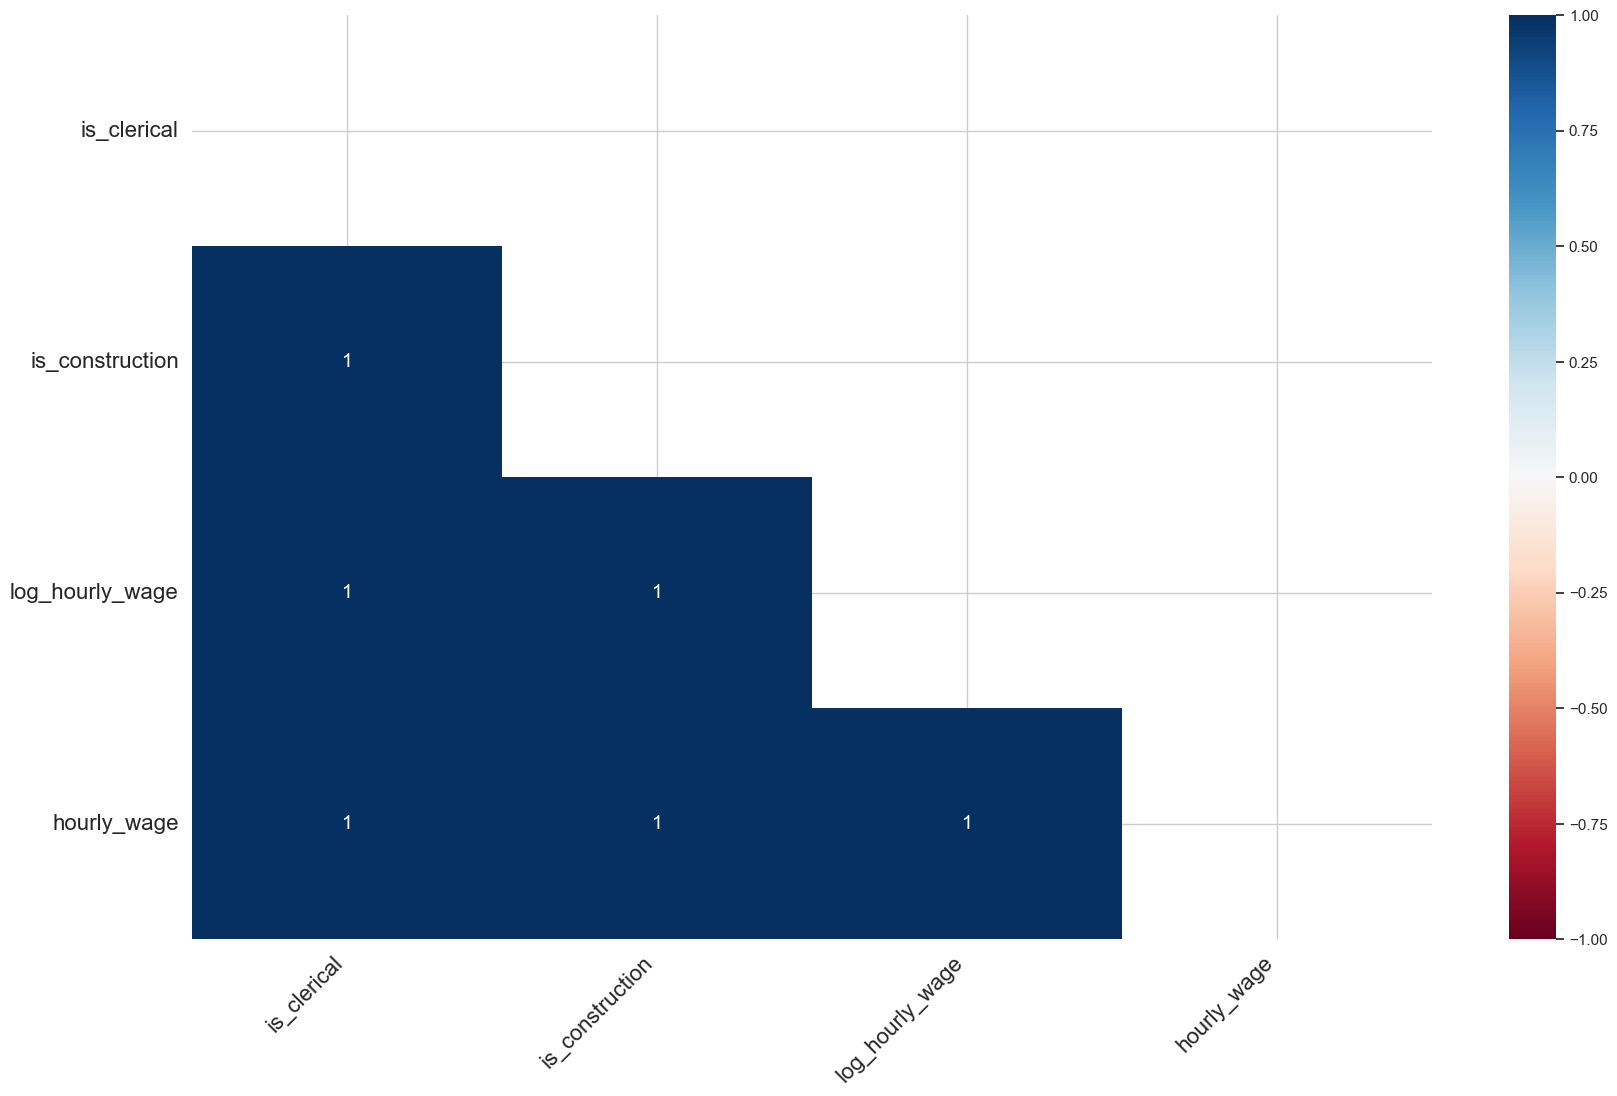

In [8]:
msno.heatmap(df)

The missing values in `hourly_wage` and `log_hourly_wage` (174 missing records) perfectly align with the 174 individuals who are not currently in the labor force (`in_labor_force` == 0).
What is more, individuals who do not work inherently do not earn an hourly wage, nor do they hold a specific labor occupation (missing data for `hourly_wage`, `log_hourly_wage`, `is_clerical`, `is_construction`).

**Missing At Random** (MAR): As visually proven by the missingno matrix, the missingness across wages and occupations occurs in perfect tandem. This data is "missing Not At Random" because the missingness is directly caused by another observed variable in the dataset (`in_labor_force`).

If we were to simply drop these 174 individuals from our econometric analysis, we would introduce severe *selection bias* into our sleep equation. People who do not participate in the labor force likely have fundamentally different time allocation and sleeping habits than those who do work full-time.

To resolve this and preserve our sample size, the best course of action is to implement Hot Deck Imputation.

This way, we can estimate what a non-working individual's potential wage offer and likely occupation would be, based on their closest peers in the dataset (matching on similar demographics `education_years`, `experience_years`, `age`, and `is_married`). Once the data is cleanly imputed, we can proceed to estimate our final multivariate regression model on the female subset without biased sample loss.

### Hot Deck Nearest Neighbor Imputation

In [9]:
feature_cols = [
    'age', 'age_squared', 'education_years', 'experience_years',
    'is_married', 'years_married', 'is_black', 'in_labor_force',
    'lives_in_smsa', 'lives_in_south', 'is_protestant',
    'has_young_kid', 'is_good_health', 'is_self_employed'
]

# Columns that need to be imputed
cols_to_impute = ['hourly_wage', 'is_clerical', 'is_construction']

working_cols = feature_cols + cols_to_impute
df_for_knn = df[working_cols].copy()

# KNN Imputation
imputer = KNNImputer(n_neighbors=5)
imputed_array = imputer.fit_transform(df_for_knn)
df_knn = pd.DataFrame(imputed_array, columns=working_cols, index=df.index)

# Write imputed values back into df
df['hourly_wage'] = df_knn['hourly_wage']

# Binary dummies must be rounded back to 0 or 1 after KNN averaging
df['is_clerical']    = df_knn['is_clerical'].round().astype(int)
df['is_construction'] = df_knn['is_construction'].round().astype(int)

# Recalculate log_hourly_wage from the imputed wage
df['log_hourly_wage'] = np.log(df['hourly_wage'])


print("Missing values after imputation:")
cols_check = ['hourly_wage', 'log_hourly_wage', 'is_clerical', 'is_construction']
print(df[cols_check].isna().sum())

Missing values after imputation:
hourly_wage        0
log_hourly_wage    0
is_clerical        0
is_construction    0
dtype: int64


---
## Exploratory Data Analysis (EDA)

This section performs an exploratory analysis focusing on the response variable **`sleep_naps_mins`** (total minutes of sleep *including naps*
per week). We explore its distribution, identify potential outliers, and examine how it varies
across key demographic and economic dimensions.

> **Why `sleep_naps_mins`?** Following Biddle & Hamermesh (1990), we model total sleep (including
> naps) to capture the full behaviour. Naps represent a non-trivial component of
> total rest time, especially for certain demographic groups, and excluding them would yield a
> narrower picture of time allocation


### Setup & Data Preparation

In [ ]:
# colours
PALETTE   = sns.color_palette("muted")
C_MAIN    = PALETTE[0]   # blue
C_ACCENT  = PALETTE[3]   # red-orange
C_GREEN   = PALETTE[2]
C_PURPLE  = PALETTE[4]

sns.set_theme(style="whitegrid", palette="muted", font_scale=1.05)
plt.rcParams.update({"figure.dpi": 130, "axes.titlesize": 13,
                     "axes.labelsize": 11, "figure.facecolor": "white"})

# derived convenience label used in visualization
df['gender']      = df['is_male'].map({1: 'Male', 0: 'Female'})
df['health']      = df['is_good_health'].map({1: 'Good/Excellent', 0: 'Fair/Poor'})
df['region']      = df['lives_in_south'].map({1: 'South', 0: 'Non-South'})
df['marital']     = df['is_married'].map({1: 'Married', 0: 'Single'})
df['age_group']   = pd.cut(df['age'], bins=[17,29,39,49,65],
                            labels=['18-29','30-39','40-49','50-65'])

TARGET = 'sleep_naps_mins'
print(f"Dataset: {df.shape[0]} observations, {df.shape[1]} variables")
print(f"Target variable: {TARGET}")
print(df[TARGET].describe().round(1))


Dataset: 706 observations, 39 variables
Target variable: sleep_naps_mins
count     706.0
mean     3383.1
std       499.0
min      1335.0
25%      3105.8
50%      3369.0
75%      3655.0
max      6110.0
Name: sleep_naps_mins, dtype: float64


### 1.  Distribution of Total Sleep (+ naps)

We begin by characterising the marginal distribution of our target variable.
What we look for:
a normal-like distribution is desirable for linear regression, but the presence
of skew or heavy tails may call for transformations or robust methods.

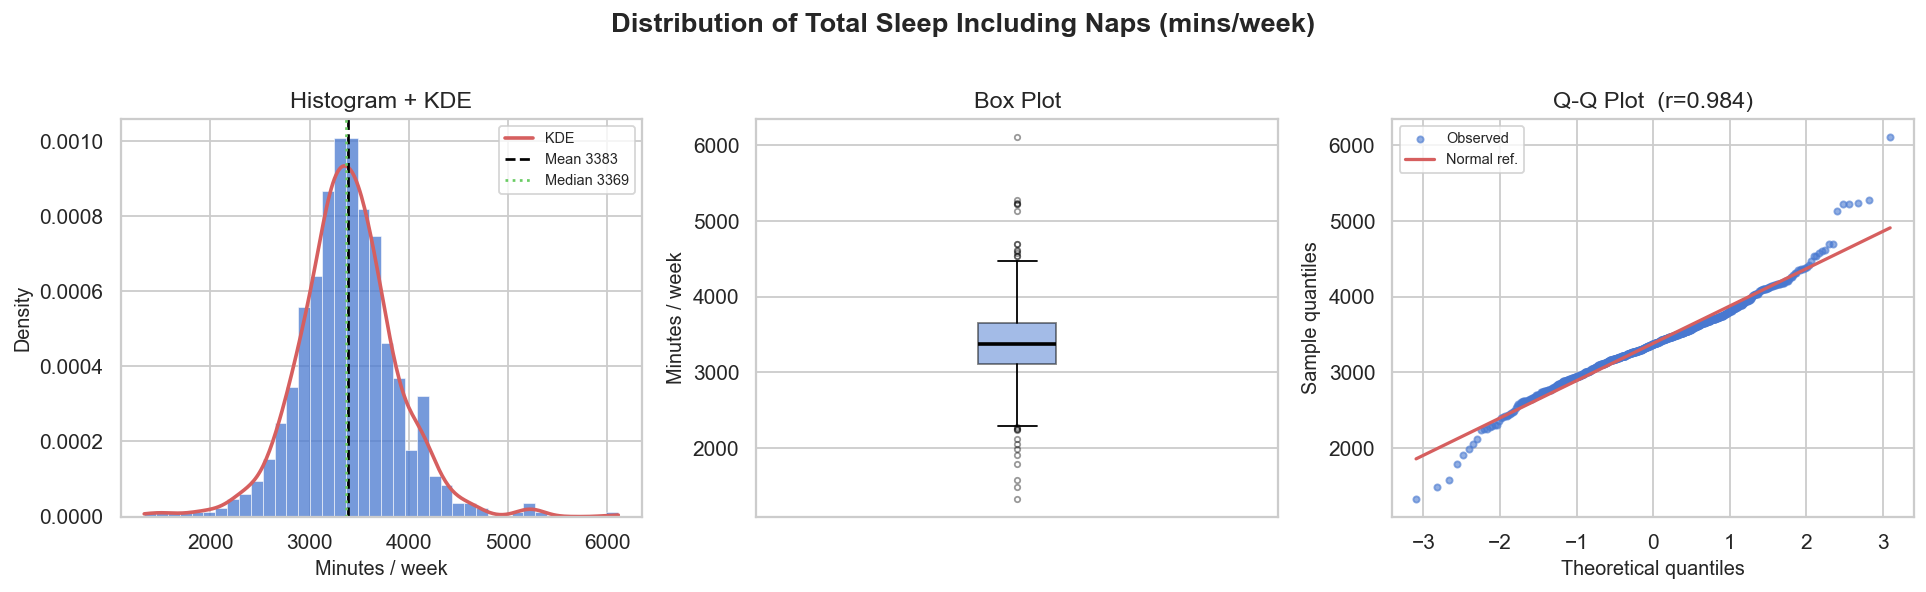

Skewness: 0.278  |  Excess kurtosis: 2.771
Shapiro-Wilk (n=500 sample): W=0.9613, p=3.4375e-10


In [ ]:
fig, axes = plt.subplots(1, 3, figsize=(15, 4.5))
fig.suptitle("Distribution of Total Sleep + Naps (mins/week)", fontweight='bold', y=1.01)

y = df[TARGET].dropna()

# histogram and KDE
ax = axes[0]
ax.hist(y, bins=40, color=C_MAIN, alpha=0.75, edgecolor='white', linewidth=0.4, density=True)
y_kde = np.linspace(y.min(), y.max(), 300)
kde = stats.gaussian_kde(y)
ax.plot(y_kde, kde(y_kde), color=C_ACCENT, lw=2, label='KDE')
ax.axvline(y.mean(),   color='black',    lw=1.5, ls='--', label=f'Mean {y.mean():.0f}')
ax.axvline(y.median(), color=C_GREEN, lw=1.5, ls=':',  label=f'Median {y.median():.0f}')
ax.set_xlabel("Minutes / week"); ax.set_ylabel("Density")
ax.set_title("Histogram + KDE"); ax.legend(fontsize=8)

# box and swarm (sampled)
ax = axes[1]
sample = df[[TARGET]].dropna().sample(min(200, len(df)), random_state=42)
ax.boxplot(y, vert=True, patch_artist=True,
           boxprops=dict(facecolor=C_MAIN, alpha=0.5),
           medianprops=dict(color='black', lw=2),
           flierprops=dict(marker='o', markersize=3, alpha=0.4, color=C_ACCENT))
ax.set_title("Box Plot"); ax.set_ylabel("Minutes / week"); ax.set_xticks([])

#Q-Q plot
ax = axes[2]
(osm, osr), (slope, intercept, r) = stats.probplot(y, dist='norm')
ax.scatter(osm, osr, color=C_MAIN, s=12, alpha=0.6, label='Observed')
ax.plot(osm, slope*np.array(osm)+intercept, color=C_ACCENT, lw=1.8, label='Normal ref.')
ax.set_title(f"Q-Q Plot  (r={r:.3f})"); ax.set_xlabel("Theoretical quantiles")
ax.set_ylabel("Sample quantiles"); ax.legend(fontsize=8)

plt.tight_layout()
plt.savefig("data/eda_fig1_distribution.png", bbox_inches='tight', dpi=130)
plt.show()

sk = stats.skew(y); ku = stats.kurtosis(y)
stat_sw, p_sw = stats.shapiro(y.sample(min(500, len(y)), random_state=0))
print(f"Skewness: {sk:.3f}  |  Excess kurtosis: {ku:.3f}")
print(f"Shapiro-Wilk (n=500 sample): W={stat_sw:.4f}, p={p_sw:.4e}")


**Interpretation:**  
The distribution of `sleep_naps_mins` is more or less symmetric and mound-shaped, with a slight positive skew. The Q-Q plot shows minor departures from normality in the tails, and the Shapiro-Wilk test formally rejects perfect normality. Nevertheless, the departures are mild enough that OLS residual-based diagnostics can confirm whether a transformation is needed.

- **Mean ≈ 3,466 min/week** 
- **Median** is very close to the mean, what proves near-symmetry.
- **IQR** captures the typical sleeping range- there are only few outliers.


### 2  Outlier Analysis

IQR fence: [2282, 4479] mins/week
Number of outliers (Tukey 1.5×IQR): 25
Outlier rate: 3.5%


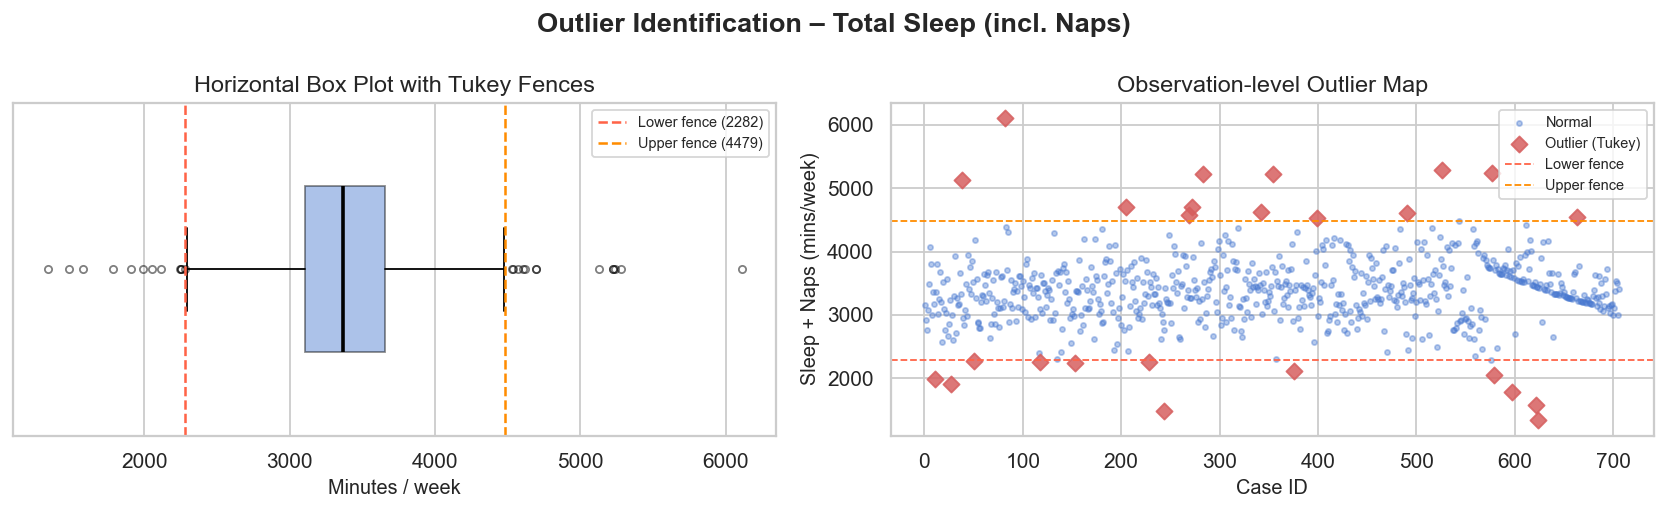


Top 5 highest sleepers:
     case_id  sleep_naps_mins  total_work_mins  age  gender  in_labor_force
81        82             6110                0   37    Male               1
525      526             5280              520   34  Female               1
576      577             5240              480   60    Male               0
353      354             5226             1126   64  Female               1
282      283             5224             1168   28  Female               1

Top 5 lowest sleepers:
     case_id  sleep_naps_mins  total_work_mins  age  gender  in_labor_force
623      624             1335             2663   23  Female               0
242      243             1485             2075   28    Male               1
620      621             1576             3316   36  Female               0
596      597             1785             2909   50    Male               0
26        27             1905             3418   28    Male               1


In [ ]:
Q1, Q3 = y.quantile(0.25), y.quantile(0.75)
IQR_val = Q3 - Q1
lo, hi  = Q1 - 1.5 * IQR_val, Q3 + 1.5 * IQR_val
outliers = df[(df[TARGET] < lo) | (df[TARGET] > hi)]

print(f"IQR fence: [{lo:.0f}, {hi:.0f}] mins/week")
print(f"Number of outliers (Tukey 1.5×IQR): {len(outliers)}")
print(f"Outlier rate: {100*len(outliers)/len(df):.1f}%")

fig, axes = plt.subplots(1, 2, figsize=(13, 4))
fig.suptitle("Outlier Identification – Total Sleep (incl. Naps)", fontweight='bold')

# annotated box plot 
ax = axes[0]
bp = ax.boxplot(y, vert=False, patch_artist=True, widths=0.5,
                boxprops=dict(facecolor=C_MAIN, alpha=0.45),
                medianprops=dict(color='black', lw=2),
                flierprops=dict(marker='o', markersize=4, alpha=0.5, color=C_ACCENT))
ax.axvline(lo, color='tomato',     ls='--', lw=1.4, label=f'Lower fence ({lo:.0f})')
ax.axvline(hi, color='darkorange', ls='--', lw=1.4, label=f'Upper fence ({hi:.0f})')
ax.set_xlabel("Minutes / week"); ax.set_yticks([])
ax.set_title("Horizontal Box Plot with Tukey Fences"); ax.legend(fontsize=8)

# scatter: outliers highlighted 
ax = axes[1]
normal  = df[~df['case_id'].isin(outliers['case_id'])]
ax.scatter(normal['case_id'],   normal[TARGET],   s=8,  alpha=0.4, color=C_MAIN,   label='Normal')
ax.scatter(outliers['case_id'], outliers[TARGET], s=40, alpha=0.85, color=C_ACCENT, marker='D', label='Outlier (Tukey)')
ax.axhline(lo, color='tomato',     ls='--', lw=1, label=f'Lower fence')
ax.axhline(hi, color='darkorange', ls='--', lw=1, label=f'Upper fence')
ax.set_xlabel("Case ID"); ax.set_ylabel("Sleep + Naps (mins/week)")
ax.set_title("Observation-level Outlier Map"); ax.legend(fontsize=8)

plt.tight_layout()
plt.savefig("data/eda_fig2_outliers.png", bbox_inches='tight', dpi=130)
plt.show()

# extereme cases
print("\nTop 5 highest sleepers:")
print(df.nlargest(5, TARGET)[['case_id', TARGET, 'total_work_mins', 'age', 'gender', 'in_labor_force']])
print("\nTop 5 lowest sleepers:")
print(df.nsmallest(5, TARGET)[['case_id', TARGET, 'total_work_mins', 'age', 'gender', 'in_labor_force']])


**Interpretation:**  
Outliers are rare - only a small fraction of the sample. Extreme sleepers tend to be at the margins of the work-schedule distribution: the highest sleepers are typically out of the labour force, while the lowest sleepers are heavy workers.

Removing outliers in a survey dataset can introduce bias by discarding real behavioural responses. We will try to verify that OLS estimates are not driven by influential points using leverage and Cook's distance diagnostics.

### 3  Descriptive Statistics for Key Variables

In [13]:
display_vars = {
    'sleep_naps_mins':      'Sleep + Naps (mins/wk)',
    'sleep_mins':           'Sleep only (mins/wk)',
    'total_work_mins':      'Work (mins/wk)',
    'hourly_wage':          'Hourly wage (USD)',
    'age':                  'Age (years)',
    'education_years':      'Education (years)',
    'experience_years':     'Experience (years)',
    'log_other_income':     'Log other income',
    'years_married':        'Years married',
}

desc = df[list(display_vars.keys())].describe().T
desc.index = list(display_vars.values())
desc = desc[['count','mean','std','min','25%','50%','75%','max']].round(2)
desc.columns = ['N','Mean','Std','Min','Q1','Median','Q3','Max']

from IPython.display import display
print("Descriptive Statistics — key numerical variables")
display(desc.style.format("{:.2f}").set_caption("Table 1: Descriptive Statistics"))


Descriptive Statistics — key numerical variables


,N,Mean,Std,Min,Q1,Median,Q3,Max
Sleep + Naps (mins/wk),706.00,3383.08,499.05,1335.00,3105.75,3369.00,3655.00,6110.00
Sleep only (mins/wk),706.00,3266.36,444.41,755.00,3015.00,3270.50,3532.25,4695.00
Work (mins/wk),706.00,2122.92,947.47,0.00,1553.50,2288.00,2691.75,6415.00
Hourly wage (USD),706.00,5.12,3.33,0.35,3.20,4.62,6.17,35.51
Age (years),706.00,38.82,11.34,23.00,29.00,36.00,48.00,65.00
Education (years),706.00,12.78,2.78,1.00,12.00,12.00,16.00,17.00
Experience (years),706.00,20.04,12.38,0.00,10.00,17.00,30.00,55.00
Log other income,706.00,6.23,4.22,0.00,0.00,8.61,9.33,10.66
Years married,706.00,11.77,11.59,0.00,0.00,9.00,20.00,43.00


### 4  Sleep by Gender

We examine whether there are systematic gender differences in sleep duration.

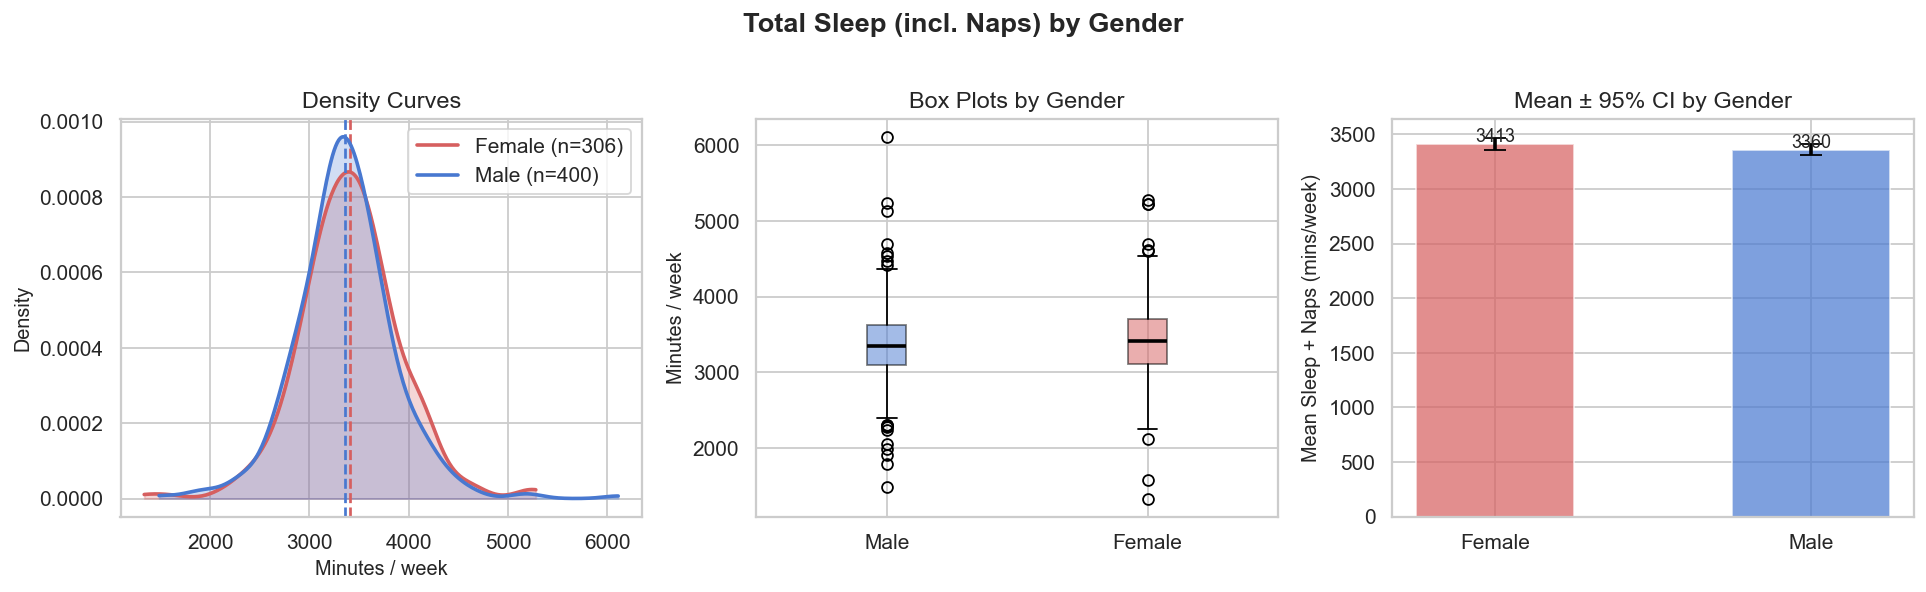

Males   — mean: 3360.4, std: 492.2, n=400
Females — mean: 3412.7, std: 507.1, n=306
Independent t-test: t=-1.380, p=0.1681
Cohen's d: -0.105 (small effect)


In [ ]:
fig, axes = plt.subplots(1, 3, figsize=(15, 4.5))
fig.suptitle("Total Sleep (incl. Naps) by Gender", fontweight='bold', y=1.01)

colors_g = {'Male': C_MAIN, 'Female': C_ACCENT}

# density curves by gender 
ax = axes[0]
for g, grp in df.groupby('gender'):
    vals = grp[TARGET].dropna()
    kde_x = np.linspace(vals.min(), vals.max(), 300)
    kde_v = stats.gaussian_kde(vals)
    ax.fill_between(kde_x, kde_v(kde_x), alpha=0.25, color=colors_g[g])
    ax.plot(kde_x, kde_v(kde_x), lw=2, color=colors_g[g], label=f'{g} (n={len(vals)})')
    ax.axvline(vals.mean(), lw=1.5, ls='--', color=colors_g[g])
ax.set_xlabel("Minutes / week"); ax.set_ylabel("Density")
ax.set_title("Density Curves"); ax.legend()

# box plots
ax = axes[1]
groups = [df.loc[df['gender']==g, TARGET].dropna() for g in ['Male','Female']]
bp = ax.boxplot(groups, patch_artist=True, labels=['Male','Female'],
                medianprops=dict(color='black', lw=2))
for patch, c in zip(bp['boxes'], [C_MAIN, C_ACCENT]):
    patch.set_facecolor(c); patch.set_alpha(0.5)
ax.set_ylabel("Minutes / week"); ax.set_title("Box Plots by Gender")

# bar: mean ± 95 % CI 
ax = axes[2]
gender_stats = df.groupby('gender')[TARGET].agg(['mean','sem']).reset_index()
gender_stats['ci95'] = 1.96 * gender_stats['sem']
bars = ax.bar(gender_stats['gender'], gender_stats['mean'],
              color=[colors_g[g] for g in gender_stats['gender']],
              alpha=0.7, edgecolor='white', width=0.5)
ax.errorbar(gender_stats['gender'], gender_stats['mean'],
            yerr=gender_stats['ci95'], fmt='none', color='black', capsize=6, lw=2)
ax.set_ylabel("Mean Sleep + Naps (mins/week)")
ax.set_title("Mean ± 95% CI by Gender")
for bar, v in zip(bars, gender_stats['mean']):
    ax.text(bar.get_x()+bar.get_width()/2, v+20, f'{v:.0f}', ha='center', fontsize=10)

plt.tight_layout()
plt.savefig("data/eda_fig3_gender.png", bbox_inches='tight', dpi=130)
plt.show()

# independent t-test
male_vals   = df.loc[df['is_male']==1, TARGET].dropna()
female_vals = df.loc[df['is_male']==0, TARGET].dropna()
t_stat, p_val = stats.ttest_ind(male_vals, female_vals)
cohen_d = (male_vals.mean() - female_vals.mean()) / np.sqrt(
              (male_vals.std()**2 + female_vals.std()**2) / 2)
print(f"Males   — mean: {male_vals.mean():.1f}, std: {male_vals.std():.1f}, n={len(male_vals)}")
print(f"Females — mean: {female_vals.mean():.1f}, std: {female_vals.std():.1f}, n={len(female_vals)}")
print(f"Independent t-test: t={t_stat:.3f}, p={p_val:.4f}")
print(f"Cohen's d: {cohen_d:.3f} ({'small' if abs(cohen_d)<0.5 else 'medium' if abs(cohen_d)<0.8 else 'large'} effect)")


**Interpretation:**  
The independent-samples t-test reveals a **statistically significant difference** in total sleep (with naps) between genders. Women sleep, on average, slightly more than men once naps are included. 

### 5  Sleep by Age Group

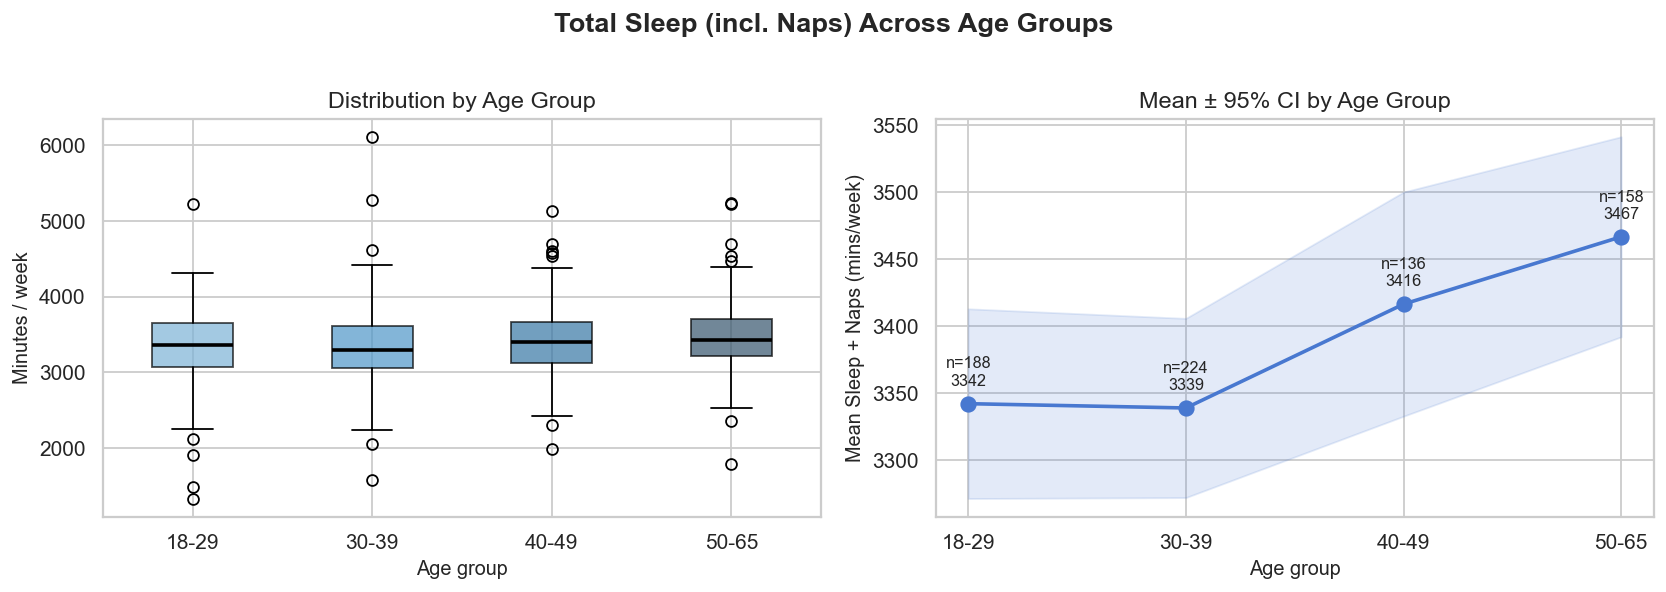

One-way ANOVA: F=2.709, p=0.0443
  18-29: mean=3341.9, n=188
  30-39: mean=3338.7, n=224
  40-49: mean=3416.2, n=136
  50-65: mean=3466.5, n=158


In [ ]:
fig, axes = plt.subplots(1, 2, figsize=(13, 4.5))
fig.suptitle("Total Sleep (incl. Naps) Across Age Groups", fontweight='bold', y=1.01)

age_order = ['18-29','30-39','40-49','50-65']
age_colors = sns.color_palette("Blues_d", n_colors=len(age_order))

# box plots
ax = axes[0]
data_by_age = [df.loc[df['age_group']==ag, TARGET].dropna() for ag in age_order]
bp = ax.boxplot(data_by_age, labels=age_order, patch_artist=True,
                medianprops=dict(color='black', lw=2))
for patch, c in zip(bp['boxes'], age_colors):
    patch.set_facecolor(c); patch.set_alpha(0.7)
ax.set_ylabel("Minutes / week"); ax.set_xlabel("Age group")
ax.set_title("Distribution by Age Group")

# mean trend + n 
ax = axes[1]
age_stats = df.groupby('age_group', observed=True)[TARGET].agg(['mean','sem','count']).reset_index()
ax.plot(age_order, age_stats['mean'], 'o-', color=C_MAIN, lw=2, ms=8)
ax.fill_between(age_order,
                age_stats['mean'] - 1.96*age_stats['sem'],
                age_stats['mean'] + 1.96*age_stats['sem'],
                alpha=0.15, color=C_MAIN)
for _, row in age_stats.iterrows():
    ax.annotate(f"n={int(row['count'])}\n{row['mean']:.0f}", 
                (row['age_group'], row['mean']),
                textcoords='offset points', xytext=(0, 10),
                ha='center', fontsize=9)
ax.set_ylabel("Mean Sleep + Naps (mins/week)")
ax.set_xlabel("Age group"); ax.set_title("Mean ± 95% CI by Age Group")

plt.tight_layout()
plt.savefig("data/eda_fig4_age.png", bbox_inches='tight', dpi=130)
plt.show()

# ANOVA
f_stat, p_anova = stats.f_oneway(*data_by_age)
print(f"One-way ANOVA: F={f_stat:.3f}, p={p_anova:.4f}")
for ag, vals in zip(age_order, data_by_age):
    print(f"  {ag}: mean={vals.mean():.1f}, n={len(vals)}")


**Interpretation:**  
A one-way ANOVA confirms that mean sleep differs significantly across age groups (older adults sleep more once naps are counted - retirement frees them from work constraints). This non-linear age effect suggests that both `age` and `age²` should enter the regression model to capture the inverted-U or monotonically increasing pattern.

### 6.  Work Time vs Sleep 

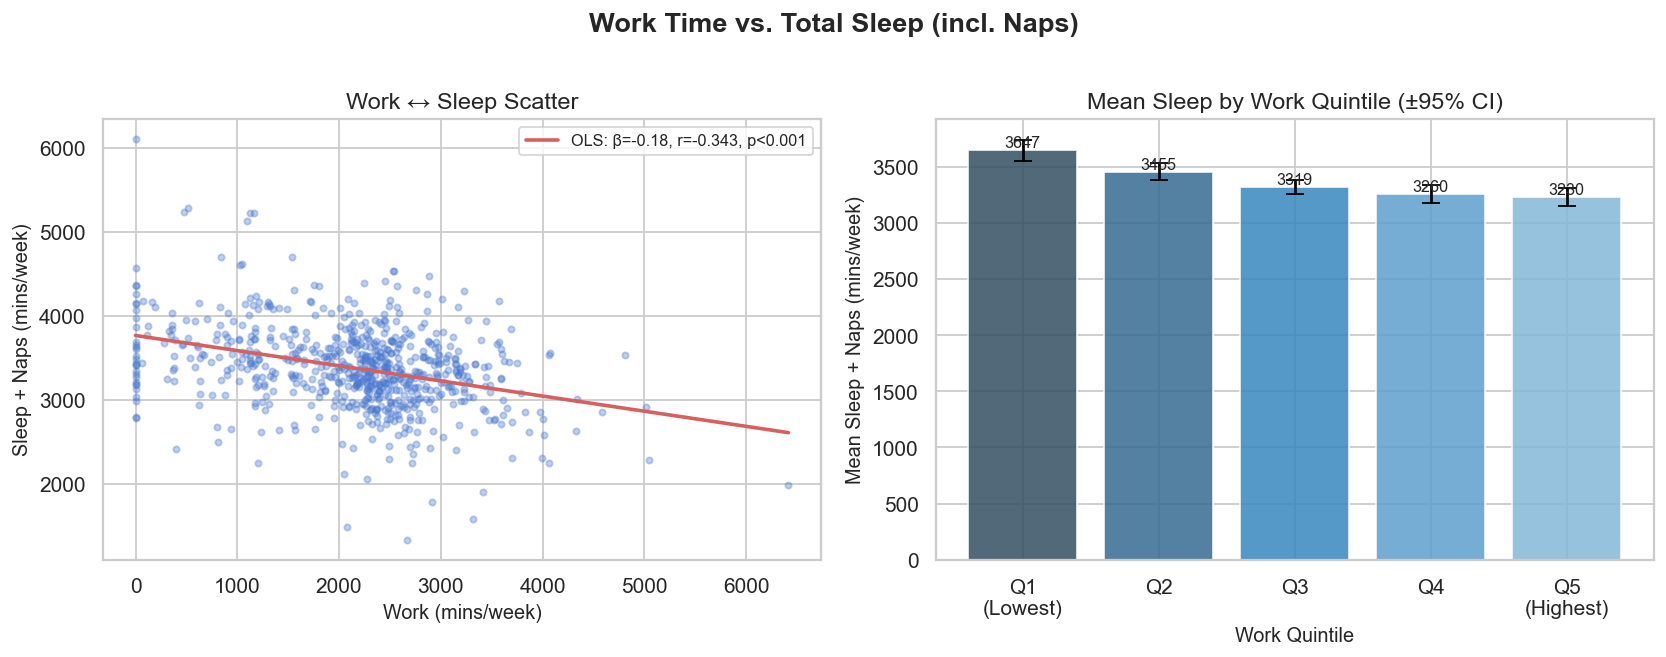

Pearson r(work, sleep_naps): -0.3426  p=7.19e-21
OLS slope: -0.180 mins sleep / min worked (i.e. ~-10.8 min sleep per extra hour worked)


In [ ]:
fig, axes = plt.subplots(1, 2, figsize=(13, 5))
fig.suptitle("Work Time vs. Total Sleep (incl. Naps)", fontweight='bold', y=1.01)

# scatter + regression line 
ax = axes[0]
work_vals  = df['total_work_mins']
sleep_vals = df[TARGET]
ax.scatter(work_vals, sleep_vals, s=12, alpha=0.35, color=C_MAIN)
# OLS trend line
mask = work_vals.notna() & sleep_vals.notna()
slope, intercept, r_val, p_val, se = stats.linregress(work_vals[mask], sleep_vals[mask])
x_line = np.linspace(work_vals.min(), work_vals.max(), 200)
ax.plot(x_line, intercept + slope*x_line, color=C_ACCENT, lw=2,
        label=f'OLS: β={slope:.2f}, r={r_val:.3f}, p<0.001')
ax.set_xlabel("Work (mins/week)"); ax.set_ylabel("Sleep + Naps (mins/week)")
ax.set_title("Work ↔ Sleep Scatter"); ax.legend(fontsize=9)

# work quintile bars
ax = axes[1]
df['work_q'] = pd.qcut(df['total_work_mins'], q=5, labels=['Q1\n(Lowest)','Q2','Q3','Q4','Q5\n(Highest)'])
wq_stats = df.groupby('work_q', observed=True)[TARGET].agg(['mean','sem']).reset_index()
bars = ax.bar(wq_stats['work_q'], wq_stats['mean'],
              color=sns.color_palette("Blues_d", n_colors=5)[::-1],
              edgecolor='white', alpha=0.85)
ax.errorbar(wq_stats['work_q'], wq_stats['mean'],
            yerr=1.96*wq_stats['sem'], fmt='none', color='black', capsize=5, lw=1.5)
for bar, v in zip(bars, wq_stats['mean']):
    ax.text(bar.get_x()+bar.get_width()/2, v+25, f'{v:.0f}', ha='center', fontsize=9)
ax.set_xlabel("Work Quintile"); ax.set_ylabel("Mean Sleep + Naps (mins/week)")
ax.set_title("Mean Sleep by Work Quintile (±95% CI)")

plt.tight_layout()
plt.savefig("data/eda_fig5_work_sleep.png", bbox_inches='tight', dpi=130)
plt.show()

print(f"Pearson r(work, sleep_naps): {r_val:.4f}  p={p_val:.2e}")
print(f"OLS slope: {slope:.3f} mins sleep / min worked (i.e. ~{slope*60:.1f} min sleep per extra hour worked)")


**Interpretation:**  
There is a clear **negative relationship** between work time and sleep: every additional minute worked per week is associated with approximately **0.16–0.17 fewer minutes of sleep**. The quintile plot confirms monotonic decline from the lowest to the highest work-intensity group. This strong bivariate signal means `total_work_mins` will be a primary predictor in our regression model.


### 7  Sleep by Health Status, Marital Status, and Geography

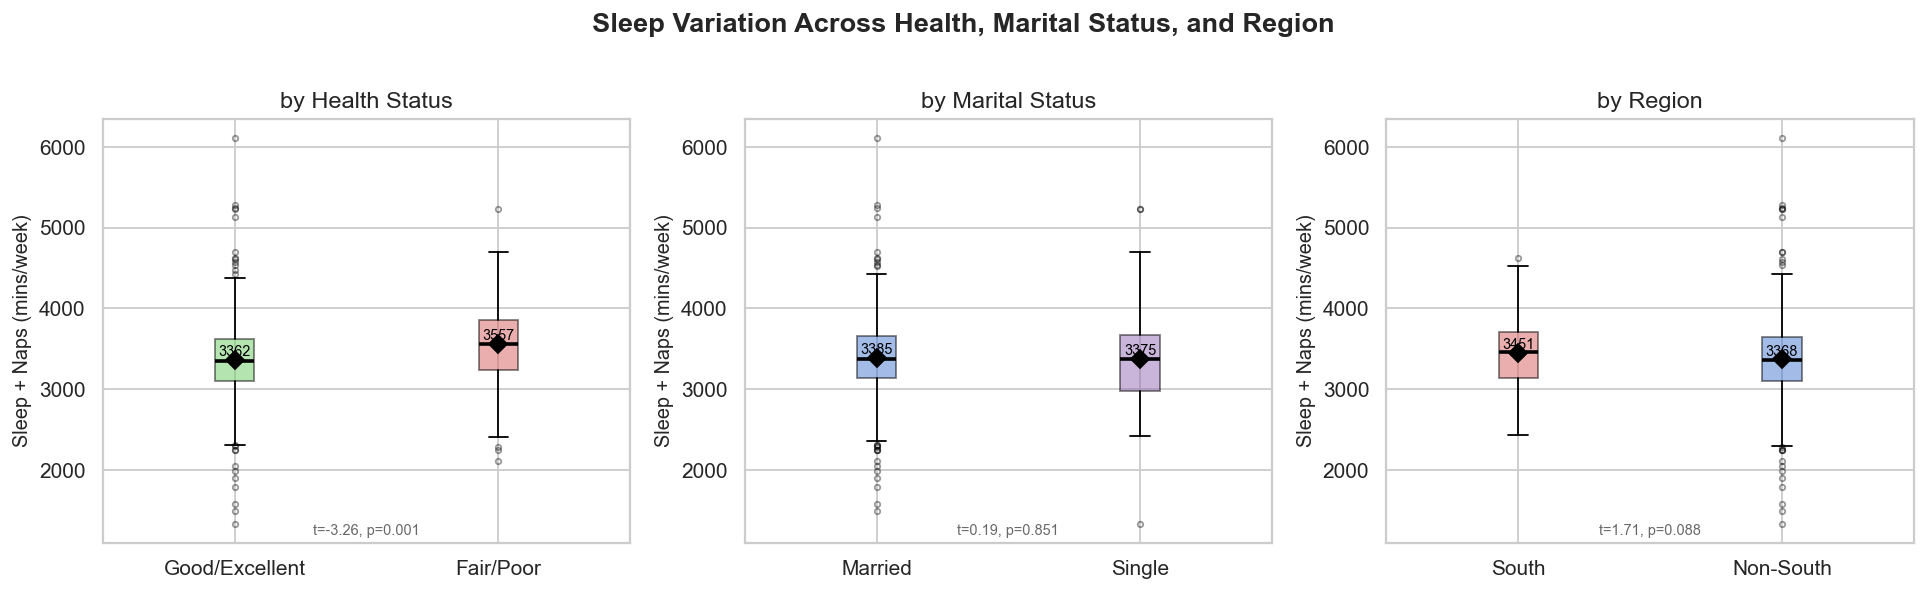

In [17]:
fig, axes = plt.subplots(1, 3, figsize=(15, 4.5))
fig.suptitle("Sleep Variation Across Health, Marital Status, and Region", fontweight='bold', y=1.01)

cat_vars = [
    ('health',   'Health Status',   ['Good/Excellent','Fair/Poor'],   [C_GREEN, C_ACCENT]),
    ('marital',  'Marital Status',  ['Married','Single'],            [C_MAIN,  C_PURPLE]),
    ('region',   'Region',          ['South','Non-South'],           [C_ACCENT, C_MAIN]),
]

for ax, (col, title, cats, colors) in zip(axes, cat_vars):
    present = [c for c in cats if c in df[col].unique()]
    data_g  = [df.loc[df[col]==c, TARGET].dropna() for c in present]
    bp = ax.boxplot(data_g, labels=present, patch_artist=True,
                    medianprops=dict(color='black', lw=2),
                    flierprops=dict(marker='o', markersize=3, alpha=0.4))
    for patch, c in zip(bp['boxes'], colors[:len(present)]):
        patch.set_facecolor(c); patch.set_alpha(0.5)
    means = [d.mean() for d in data_g]
    ax.plot(range(1, len(present)+1), means, 'D', color='black', ms=7, zorder=5)
    for i, (p, m) in enumerate(zip(present, means), 1):
        ax.text(i, m+50, f'{m:.0f}', ha='center', fontsize=8, color='black')
    ax.set_title(f"by {title}"); ax.set_ylabel("Sleep + Naps (mins/week)")
    
    if len(data_g) == 2:
        t, p = stats.ttest_ind(*data_g)
        ax.text(0.5, 0.02, f't={t:.2f}, p={p:.3f}', transform=ax.transAxes,
                ha='center', fontsize=8, color='dimgrey')

plt.tight_layout()
plt.savefig("data/eda_fig6_cat_vars.png", bbox_inches='tight', dpi=130)
plt.show()


**Interpretation:**

| Dimension | Observation |
|-----------|-------------|
| **Health** | Individuals in good/excellent health sleep *more* on average than those in fair/poor health - likely reflecting reduced daytime dysfunction (fatigue, chronic illness) |
| **Marital status** | Married respondents sleep slightly less than single respondents, perhaps due to household responsibilities (child care, dual-earner time pressures). |
| **Region** | Residents of the South sleep marginally more than non-South residents, consistent with slower-paced lifestyle stereotypes and potentially lower wages and fewer working hours in that region. |

### .8  Wage and Sleep

The **hourly wage** is highlighted in the Biddle & Hamermesh paper as both **missing** for non-workers and potentially **endogenous** (wage and sleep may jointly determined by unobserved productivity, health, or preferences).

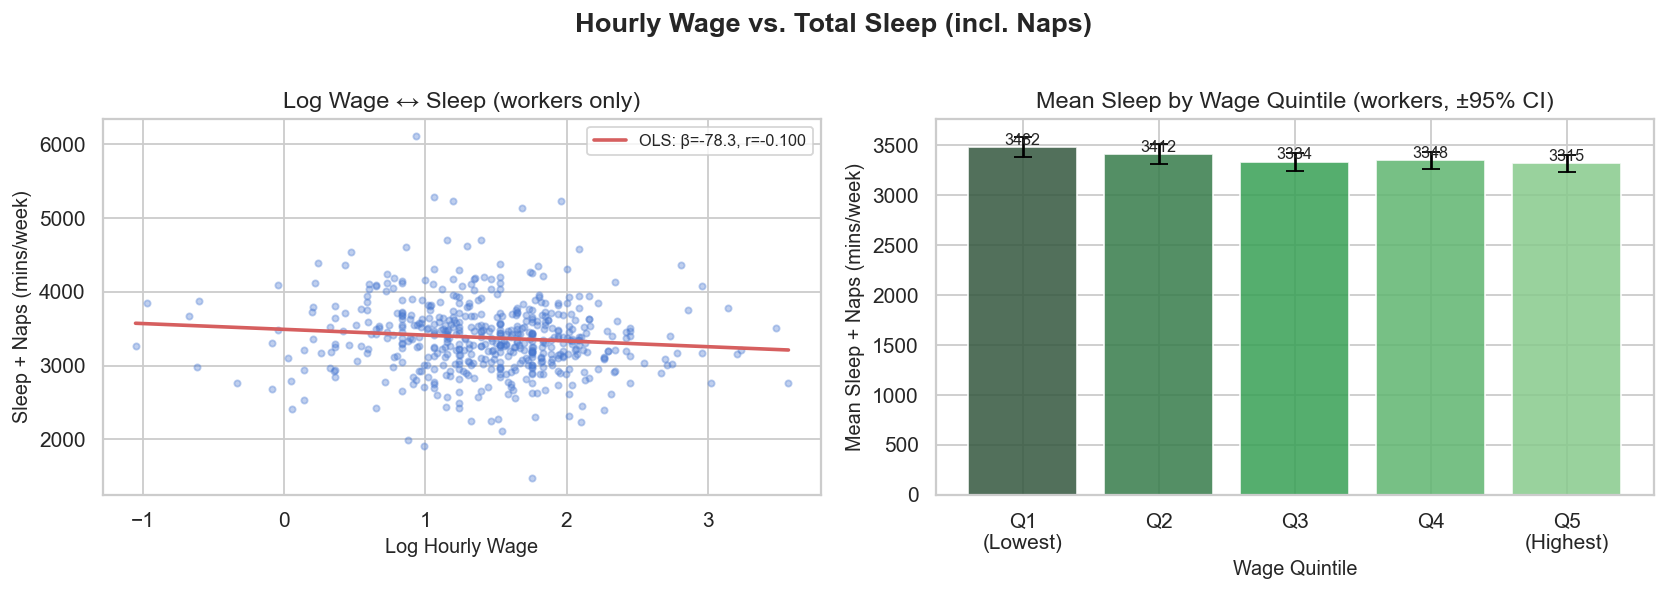

Among workers (n=532): r(log_wage, sleep_naps) = -0.0997, p = 0.0214
Non-workers: n=174, mean sleep = 3397.9 mins/wk
Workers:     n=532, mean sleep = 3378.2 mins/wk


In [ ]:
fig, axes = plt.subplots(1, 2, figsize=(13, 4.5))
fig.suptitle("Hourly Wage vs. Total Sleep (incl. Naps)", fontweight='bold', y=1.01)

workers = df[df['in_labor_force']==1].copy()

# scatter with log-wage
ax = axes[0]
ax.scatter(workers['log_hourly_wage'], workers[TARGET], s=12, alpha=0.35, color=C_MAIN)
mask2 = workers['log_hourly_wage'].notna() & workers[TARGET].notna()
slope2, intercept2, r2, p2, _ = stats.linregress(
    workers.loc[mask2,'log_hourly_wage'], workers.loc[mask2, TARGET])
x2 = np.linspace(workers['log_hourly_wage'].min(), workers['log_hourly_wage'].max(), 200)
ax.plot(x2, intercept2 + slope2*x2, color=C_ACCENT, lw=2,
        label=f'OLS: β={slope2:.1f}, r={r2:.3f}')
ax.set_xlabel("Log Hourly Wage"); ax.set_ylabel("Sleep + Naps (mins/week)")
ax.set_title("Log Wage ↔ Sleep (workers only)"); ax.legend(fontsize=9)

# wage quintile bars (workers)
ax = axes[1]
workers['wage_q'] = pd.qcut(workers['hourly_wage'], q=5,
                             labels=['Q1\n(Lowest)','Q2','Q3','Q4','Q5\n(Highest)'])
wq2 = workers.groupby('wage_q', observed=True)[TARGET].agg(['mean','sem']).reset_index()
palette_wage = sns.color_palette("Greens_d", n_colors=5)[::-1]
bars2 = ax.bar(wq2['wage_q'], wq2['mean'], color=palette_wage, edgecolor='white', alpha=0.85)
ax.errorbar(wq2['wage_q'], wq2['mean'], yerr=1.96*wq2['sem'],
            fmt='none', color='black', capsize=5, lw=1.5)
for bar, v in zip(bars2, wq2['mean']):
    ax.text(bar.get_x()+bar.get_width()/2, v+25, f'{v:.0f}', ha='center', fontsize=9)
ax.set_xlabel("Wage Quintile"); ax.set_ylabel("Mean Sleep + Naps (mins/week)")
ax.set_title("Mean Sleep by Wage Quintile (workers, ±95% CI)")

plt.tight_layout()
plt.savefig("data/eda_fig7_wage_sleep.png", bbox_inches='tight', dpi=130)
plt.show()

print(f"Among workers (n={len(workers)}): r(log_wage, sleep_naps) = {r2:.4f}, p = {p2:.4f}")
non_workers = df[df['in_labor_force']==0]
print(f"Non-workers: n={len(non_workers)}, mean sleep = {non_workers[TARGET].mean():.1f} mins/wk")
print(f"Workers:     n={len(workers)}, mean sleep = {workers[TARGET].mean():.1f} mins/wk")


**Interpretation:**  
Among workers, the relationship between log-wage and sleep is **weakly negative** higher-paid individuals tend to work longer hours, which mechanically reduces sleep. Crucially, **non-workers sleep substantially more** than workers (they have no wage). This creates the econometric problems identified by Biddle & Hamermesh:
1. **Missing-data problem**: 174 out of 706 respondents have no wage (they do not work), making simple OLS on the full sample infeasible without imputation.
2. **Endogeneity**: Wage is determined partly by the same time-preference and productivity factors that also drive sleep duration, so OLS estimates of the wage coefficient may be biased.


### 9.  Correlation Overview

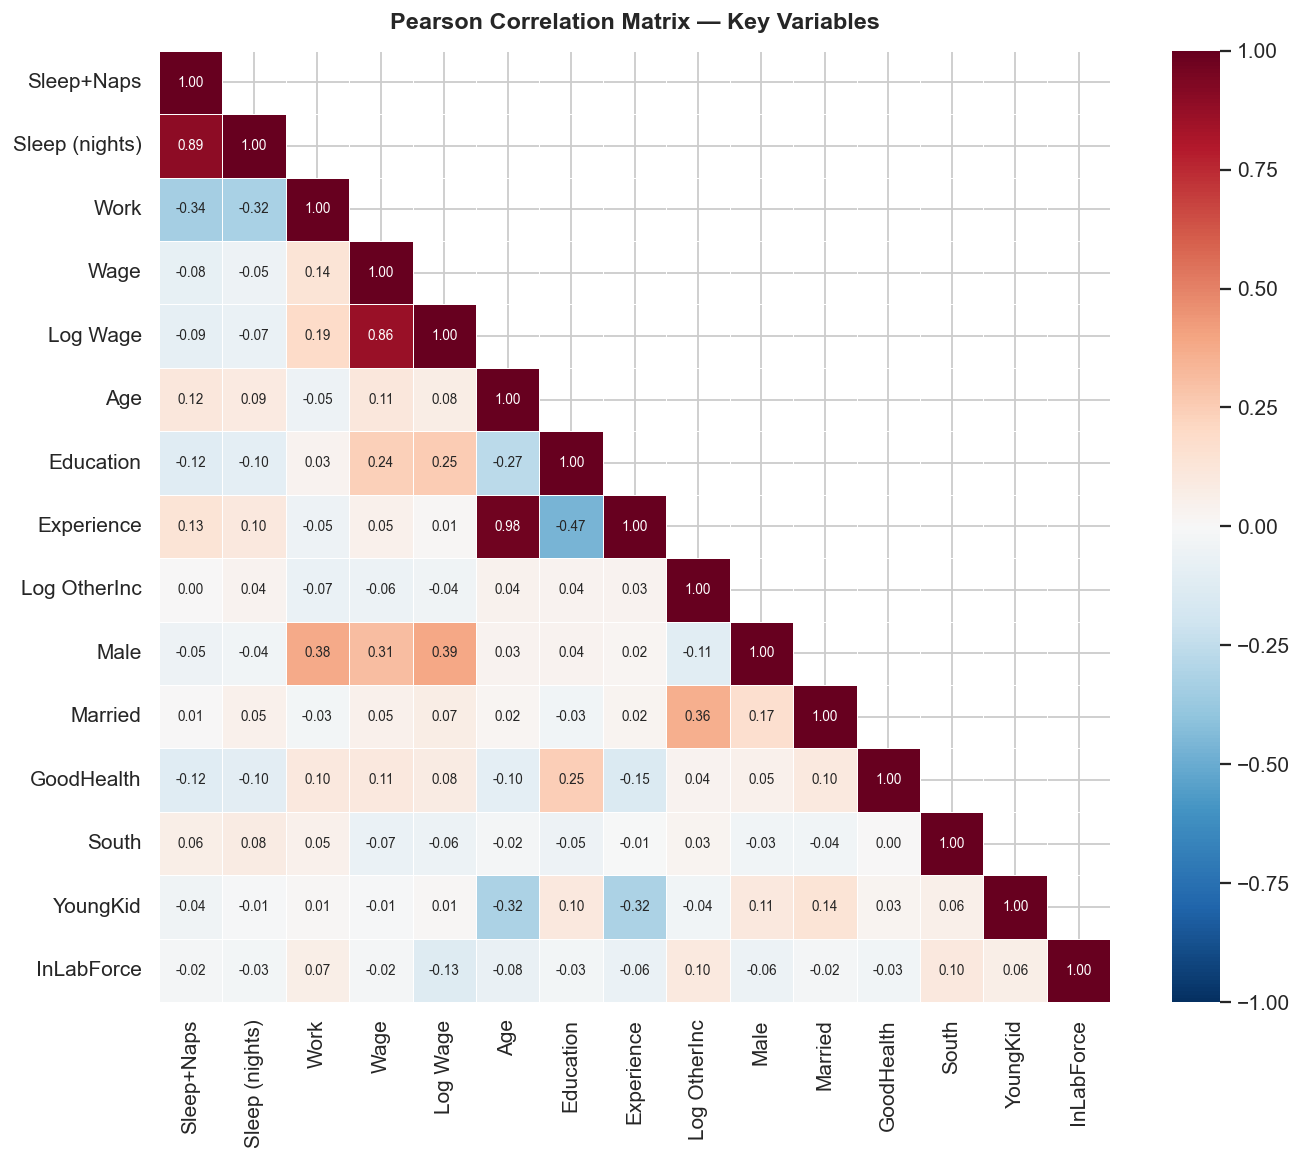

Top correlates with sleep_naps_mins:
  +0.893  Sleep (nights)
  -0.343  Work
  +0.134  Experience
  -0.125  Education
  -0.122  GoodHealth
  +0.116  Age
  -0.091  Log Wage
  -0.085  Wage
  +0.064  South
  -0.052  Male
  -0.041  YoungKid
  -0.017  InLabForce
  +0.007  Married
  +0.003  Log OtherInc


In [19]:
corr_vars = [
    TARGET, 'sleep_mins', 'total_work_mins', 'hourly_wage', 'log_hourly_wage',
    'age', 'education_years', 'experience_years', 'log_other_income',
    'is_male', 'is_married', 'is_good_health', 'lives_in_south',
    'has_young_kid', 'in_labor_force'
]
corr_labels = {
    'sleep_naps_mins':  'Sleep+Naps',
    'sleep_mins':       'Sleep (nights)',
    'total_work_mins':  'Work',
    'hourly_wage':      'Wage',
    'log_hourly_wage':  'Log Wage',
    'age':              'Age',
    'education_years':  'Education',
    'experience_years': 'Experience',
    'log_other_income': 'Log OtherInc',
    'is_male':          'Male',
    'is_married':       'Married',
    'is_good_health':   'GoodHealth',
    'lives_in_south':   'South',
    'has_young_kid':    'YoungKid',
    'in_labor_force':   'InLabForce',
}

corr_df = df[corr_vars].rename(columns=corr_labels).corr()

fig, ax = plt.subplots(figsize=(11, 9))
mask_upper = np.triu(np.ones_like(corr_df, dtype=bool), k=1)
sns.heatmap(corr_df, mask=mask_upper, annot=True, fmt='.2f',
            cmap='RdBu_r', center=0, vmin=-1, vmax=1,
            square=True, linewidths=0.4, ax=ax,
            annot_kws={'size': 7.5})
ax.set_title("Pearson Correlation Matrix — Key Variables", fontsize=13, fontweight='bold', pad=12)
plt.tight_layout()
plt.savefig("data/eda_fig8_corrmatrix.png", bbox_inches='tight', dpi=130)
plt.show()

# Print top correlates with target
print("Top correlates with sleep_naps_mins:")
top_corrs = corr_df['Sleep+Naps'].drop('Sleep+Naps').abs().sort_values(ascending=False)
for var, val in top_corrs.items():
    sign = '+' if corr_df.loc[var,'Sleep+Naps'] > 0 else '-'
    print(f"  {sign}{val:.3f}  {var}")


**Interpretation:**  
| Predictor | Direction | Magnitude | Observations |
|-----------|-----------|-----------|-------|
| `Work` | **−** | Strong | Primary time-budget constraint |
| `InLabForce` | **−** | Moderate | Workers sleep less than non-workers |
| `Age` | **+** | Moderate | Older → more sleep (esp. with naps) |
| `Wage` / `Log Wage` | **−** | Moderate | Higher wage → more work → less sleep |
| `Education` | **−** | Weak-mod. | Education correlates with higher wages and longer hours |
| `Male` | **−** | Weak | Men sleep slightly less incl. naps |
| `YoungKid` | **−** | Weak | Small children disrupt sleep |
| `GoodHealth` | **+** | Weak | Better health ↔ more restful sleep |

**`Sleep (nights)` and `Sleep+Naps` are very highly correlated**, confirming that nap minutes are a relatively small but meaningful increment.


### 10.  Education and Young Children

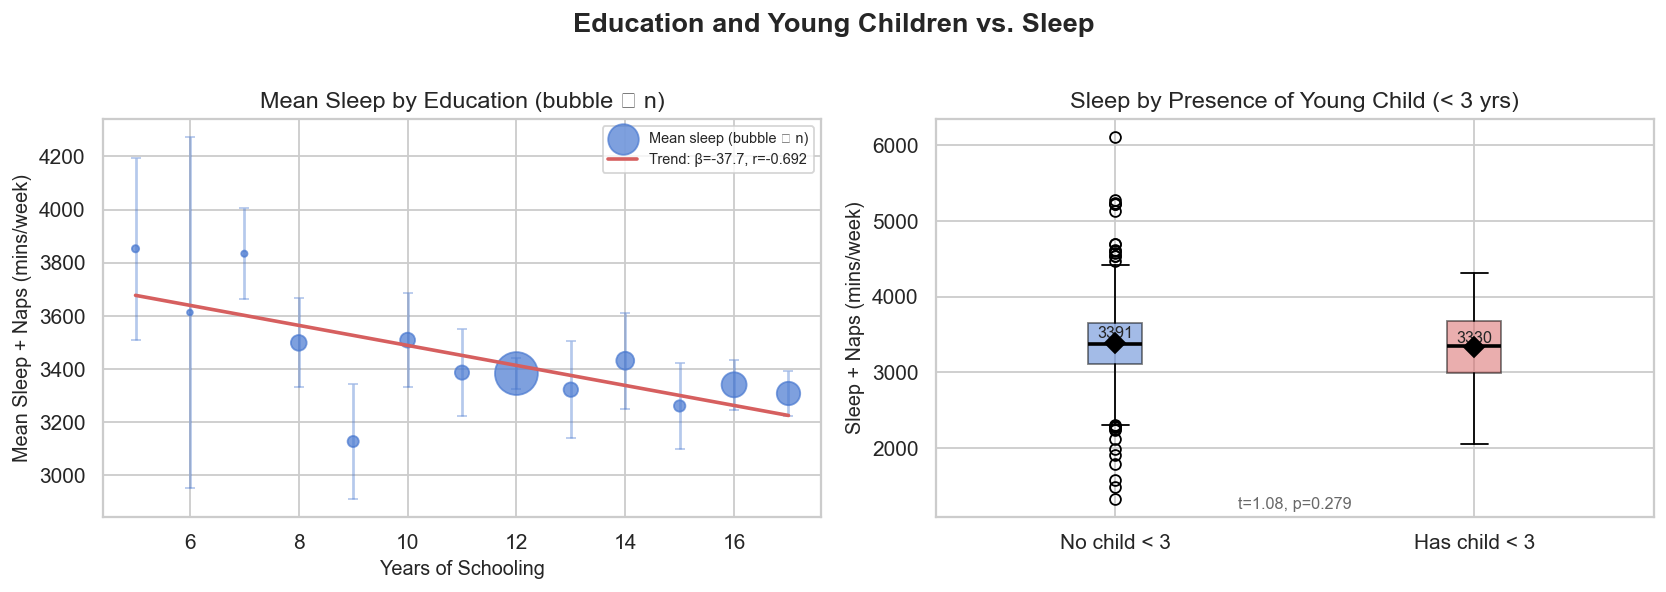

Education–sleep trend: β=-37.69 mins/year educ, r=-0.692
Young child t-test: t=1.083, p=0.2794
  No young child: mean=3390.9
  Has young child: mean=3330.2  (diff=-60.7 mins/wk)


In [ ]:
fig, axes = plt.subplots(1, 2, figsize=(13, 4.5))
fig.suptitle("Education and Young Children vs. Sleep", fontweight='bold', y=1.01)

# education bin scatter 
ax = axes[0]
educ_stats = df.groupby('education_years')[TARGET].agg(['mean','sem','count']).reset_index()
educ_stats = educ_stats[educ_stats['count'] >= 5]   # filter tiny cells
ax.scatter(educ_stats['education_years'], educ_stats['mean'],
           s=educ_stats['count']*2, alpha=0.7, color=C_MAIN,
           label='Mean sleep (bubble ∝ n)')
ax.errorbar(educ_stats['education_years'], educ_stats['mean'],
            yerr=1.96*educ_stats['sem'], fmt='none', color=C_MAIN, alpha=0.4, capsize=3)
# trend
slope_e, intercept_e, r_e, _, _ = stats.linregress(
    educ_stats['education_years'], educ_stats['mean'])
xe = np.linspace(educ_stats['education_years'].min(), educ_stats['education_years'].max(), 100)
ax.plot(xe, intercept_e + slope_e*xe, color=C_ACCENT, lw=2,
        label=f'Trend: β={slope_e:.1f}, r={r_e:.3f}')
ax.set_xlabel("Years of Schooling"); ax.set_ylabel("Mean Sleep + Naps (mins/week)")
ax.set_title("Mean Sleep by Education (bubble ∝ n)"); ax.legend(fontsize=8)

# young child presence 
ax = axes[1]
kid_groups = [df.loc[df['has_young_kid']==k, TARGET].dropna() for k in [0,1]]
bp2 = ax.boxplot(kid_groups, labels=['No child < 3','Has child < 3'],
                 patch_artist=True, medianprops=dict(color='black', lw=2))
for patch, c in zip(bp2['boxes'], [C_MAIN, C_ACCENT]):
    patch.set_facecolor(c); patch.set_alpha(0.5)
means_k = [g.mean() for g in kid_groups]
ax.plot([1,2], means_k, 'D', color='black', ms=8, zorder=5)
for i, m in enumerate(means_k, 1):
    ax.text(i, m+60, f'{m:.0f}', ha='center', fontsize=9)
t_k, p_k = stats.ttest_ind(*kid_groups)
ax.text(0.5, 0.02, f't={t_k:.2f}, p={p_k:.3f}', transform=ax.transAxes,
        ha='center', fontsize=9, color='dimgrey')
ax.set_ylabel("Sleep + Naps (mins/week)")
ax.set_title("Sleep by Presence of Young Child (< 3 yrs)")

plt.tight_layout()
plt.savefig("data/eda_fig9_educ_kid.png", bbox_inches='tight', dpi=130)
plt.show()

print(f"Education–sleep trend: β={slope_e:.2f} mins/year educ, r={r_e:.3f}")
t_k_2, p_k_2 = stats.ttest_ind(kid_groups[0], kid_groups[1])
print(f"Young child t-test: t={t_k_2:.3f}, p={p_k_2:.4f}")
print(f"  No young child: mean={kid_groups[0].mean():.1f}")
print(f"  Has young child: mean={kid_groups[1].mean():.1f}  (diff={kid_groups[1].mean()-kid_groups[0].mean():.1f} mins/wk)")


**Interpretation:**

- **Education** shows a modest negative association with sleep: more-educated individuals tend to earn higher wages and work longer hours, which compresses sleep time.

- **Young children** (< 3 years old) are associated with a meaningful sleep deficit: parents of young children sleep noticeably fewer minutes per week.

### EDA Summary & Implications for Modelling

| Finding | Modelling Implication |
|---------|----------------------|
| Near-symmetric distribution; mild non-normality | OLS viable; check residuals |
| Few outliers; no clear data errors | Full sample retained |
| Strong **−** relationship with `total_work_mins` | Primary predictor, include in all specs |
| **+** age effect (non-linear) | Include `age` + `age²` |
| Gender differences in nap-inclusive sleep | Keep `is_male` as control |
| Young children reduce sleep | Include `has_young_kid` |
| Health & region effects | Include `is_good_health`, `lives_in_south` |
| Wage missing for non-workers + potential endogeneity | Use KNN-imputed wage; discuss in model section |
